In [1]:
# 动力学参数辨识 更新 AtoB 的绘图框架，以便快速用于对比 sim 和 real 的数据
# 并能够批量化做参数寻找
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import scipy.io
import matplotlib.pyplot as plt
import pandas as pd


damping1_sim: 47.89473684210526, damping2_sim: 100.0
pressure1_start_sim: 30000.0, pressure2_start_sim: 10000.0


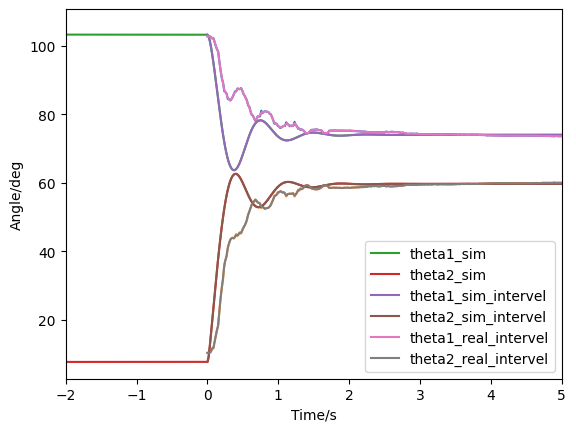

In [2]:
# 预处理数据
# settings
start_step_time = 5
data_real_path = '../data/Archive/A2Bdata/ToCenter_2025-02-20_21-06-20_A2B_data.csv'
group_id_real = 19
group_id_sim = 199

folder_path = '../data/SimConstrastResults/AtoB_realsim_constrast_20250224170332'  # 替换为你的文件夹路径
npy_files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]
# print the name by order
npy_files.sort()

data_list = []
for file_name in npy_files:
    file_path = os.path.join(folder_path, file_name)
    data = np.load(file_path)
    data_list.append(data)

data_sim = data_list[group_id_sim]['arr_0']
damping1_sim = data_sim[0,0]
damping2_sim = data_sim[0,1]
pressure1_start_sim = data_sim[0,2]
pressure2_start_sim = data_sim[0,3]
print(f"damping1_sim: {damping1_sim}, damping2_sim: {damping2_sim}")
print(f"pressure1_start_sim: {pressure1_start_sim}, pressure2_start_sim: {pressure2_start_sim}")
time_sim = data_sim[:,4]-10
theta1_sim = (data_sim[:,5]+math.pi/2)*180/np.pi
theta2_sim = (data_sim[:,6]+math.pi/2)*180/np.pi
# plt.plot(time_sim, theta1_sim, label='theta1_sim')
# plt.plot(time_sim, theta2_sim, label='theta2_sim')
# plt.legend()
# plt.show()

# 原始数据：角度为 deg, 具有 pressure1_start, pressure2_start, pressure1_end, pressure2_end, relative_time, thigh_theta21, calf_theta32
data_real = pd.read_csv(data_real_path)    # Goup 3
data_real["experiment_group"] = data_real.groupby(["pressure1_start", "pressure2_start", "pressure1_end", 
                                     "pressure2_end"]).ngroup()
group_data_real_dic = {}    # using group_id to get the group_data_real
for group_id in data_real["experiment_group"].unique():
    # 访问某组数据
    group_data_real = data_real[data_real["experiment_group"]==group_id]
    # 访问时间
    group_data_real = group_data_real[group_data_real["relative_time"]>=start_step_time]
    pressure1_start = group_data_real["pressure1_start"].iloc[0]    # 访问group 参数
    pressure2_start = group_data_real["pressure2_start"].iloc[0]
    pressure1_end = group_data_real["pressure1_end"].iloc[0]
    pressure2_end = group_data_real["pressure2_end"].iloc[0]
    time_real = np.array(group_data_real["relative_time"]-start_step_time)  # 访问实验数据
    theta1_real = np.array(group_data_real["thigh_theta21"])
    theta2_real = np.array(group_data_real["calf_theta32"])
    group_data_real_dic[group_id] = {
        "pressure1_start": pressure1_start,
        "pressure2_start": pressure2_start,
        "pressure1_end": pressure1_end,
        "pressure2_end": pressure2_end,
        "time_real": time_real,
        "theta1_real": theta1_real,
        "theta2_real": theta2_real
    }

data_real_analysis = group_data_real_dic[group_id_real]
plt.plot(data_real_analysis["time_real"], data_real_analysis["theta1_real"])
plt.plot(data_real_analysis["time_real"], data_real_analysis["theta2_real"])
plt.plot(time_sim, theta1_sim, label='theta1_sim')
plt.plot(time_sim, theta2_sim, label='theta2_sim')
plt.xlim(-2, 5)
plt.xlabel("Time/s")
plt.ylabel("Angle/deg")

# check 插值
t_intervel = np.linspace(0, 5, 300)
theta1_sim_intervel = np.interp(t_intervel, time_sim, theta1_sim)
theta2_sim_intervel = np.interp(t_intervel, time_sim, theta2_sim)
theta1_real_intervel = np.interp(t_intervel, data_real_analysis["time_real"], data_real_analysis["theta1_real"])
theta2_real_intervel = np.interp(t_intervel, data_real_analysis["time_real"], data_real_analysis["theta2_real"])
plt.plot(t_intervel, theta1_sim_intervel, label='theta1_sim_intervel')
plt.plot(t_intervel, theta2_sim_intervel, label='theta2_sim_intervel')
plt.plot(t_intervel, theta1_real_intervel, label='theta1_real_intervel')
plt.plot(t_intervel, theta2_real_intervel, label='theta2_real_intervel')
plt.legend()



Find the min MSE at 399
100.0 100.0


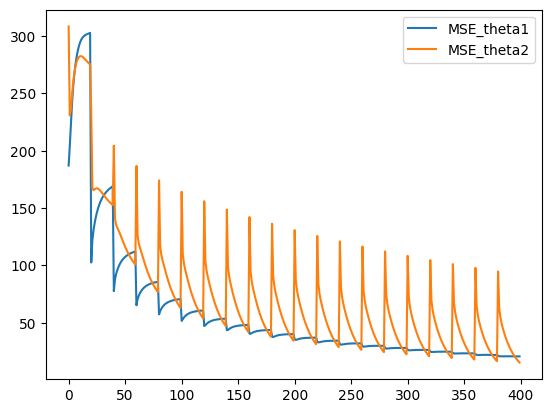

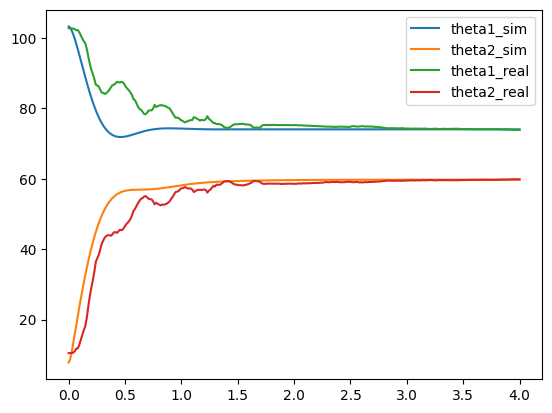

Optimal 100.0, 100.0
(np.float64(20.675140611526743), np.float64(15.393171721608724), np.float64(15.66059360060649), np.float64(14.536273258832079))


In [3]:
def cal_error(t_sim, theta1_sim, theta2_sim, t_real, theta1_real, theta2_real, plot=False):
    t_intervel = np.linspace(0, 4, 300)
    theta1_sim_intervel = np.interp(t_intervel, t_sim, theta1_sim)
    theta2_sim_intervel = np.interp(t_intervel, t_sim, theta2_sim)
    theta1_real_intervel = np.interp(t_intervel, t_real, theta1_real)
    theta2_real_intervel = np.interp(t_intervel, t_real, theta2_real)

    mse_theta1 = np.mean(np.square(theta1_sim_intervel-theta1_real_intervel))
    mse_theta2 = np.mean(np.square(theta2_sim_intervel-theta2_real_intervel))
    maxerror_theta1 = np.max(np.abs(theta1_sim_intervel-theta1_real_intervel))
    maxerror_theta2 = np.max(np.abs(theta2_sim_intervel-theta2_real_intervel))


    if plot:
        plt.plot(t_intervel, theta1_sim_intervel, label='theta1_sim')
        plt.plot(t_intervel, theta2_sim_intervel, label='theta2_sim')
        plt.plot(t_intervel, theta1_real_intervel, label='theta1_real')
        plt.plot(t_intervel, theta2_real_intervel, label='theta2_real')
        legend = plt.legend()
        plt.show()

    # print(f"MSE_theta_1[0-4s]={mse_theta1}deg^2")
    # print(f"MaxError_theta_1[0-4s]={maxerror_theta1}deg")
    # print(f"MSE_theta_2[0-4s]={mse_theta2}deg^2")
    # print(f"MaxError_theta_2[0-4s]={maxerror_theta2}deg")
    return mse_theta1, mse_theta2, maxerror_theta1, maxerror_theta2

Error_array = []
for data in data_list:
    data_sim = data['arr_0']
    damping1_sim = data_sim[0,0]
    damping2_sim = data_sim[0,1]
    pressure1_start_sim = data_sim[0,2]
    pressure2_start_sim = data_sim[0,3]
    time_sim = data_sim[:,4]-10
    theta1_sim = (data_sim[:,5]+math.pi/2)*180/np.pi
    theta2_sim = (data_sim[:,6]+math.pi/2)*180/np.pi
    error = cal_error(time_sim, theta1_sim, theta2_sim, data_real_analysis["time_real"], data_real_analysis["theta1_real"], data_real_analysis["theta2_real"])
    Error_array.append(error)
    # print("error:", error)

# 绘制误差图
Error_array = np.array(Error_array)
plt.plot(Error_array[:,0], label="MSE_theta1")
plt.plot(Error_array[:,1], label="MSE_theta2")
# plt.plot(Error_array[:,2], label="MaxError_theta1")
# plt.plot(Error_array[:,3], label="MaxError_theta2")
plt.legend()
# plt.ylim(0,15)

plt.figure()
# target: find the c1, c2 that minize the (MSE1 + MSE2)
MSE_array = Error_array[:,0] + Error_array[:,1]
min_index = np.argmin(MSE_array)
print(f"Find the min MSE at {min_index}")
# print the parameters
c1 = data_list[min_index]['arr_0'][0, 0]
c2 = data_list[min_index]['arr_0'][0, 1]
print(c1, c2)

# plot the optimal
data = data_list[min_index]
data_sim = data['arr_0']
damping1_sim = data_sim[0,0]
damping2_sim = data_sim[0,1]
pressure1_start_sim = data_sim[0,2]
pressure2_start_sim = data_sim[0,3]
time_sim = data_sim[:,4]-10
theta1_sim = (data_sim[:,5]+math.pi/2)*180/np.pi
theta2_sim = (data_sim[:,6]+math.pi/2)*180/np.pi
error = cal_error(time_sim, theta1_sim, theta2_sim, data_real_analysis["time_real"], data_real_analysis["theta1_real"], data_real_analysis["theta2_real"], plot=True)
print(f"Optimal {damping1_sim}, {damping2_sim}")
print(error)

# 寻找：MaxError_theta1<5deg
for i, error in enumerate(Error_array):
    # print(error)
    if error[2] < 5 and error[0] < 5:
        print(f"Find the MaxError_theta(1&2) < 10deg at {i}")
        break

